# Tostao - Caso A: Optimizacion de Abastecimiento
## Pronostico de Demanda SKU-Tienda + Modelo de Pedido Optimo
---
**Rol:** Lead Data Scientist  
**Objetivo:** Pronosticar la demanda semanal por SKU-Tienda y determinar la cantidad optima de pedido minimizando el costo total esperado (stockout vs overstock).

**Datasets:** `ventas_historicas`, `catalogo_productos`, `inventario_actual`, `maestro_tiendas`

## 0. Setup y librerias

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from IPython.display import display

from src.data_cleaning import load_raw_tables, validate_dataset
from src.feature_engineering import (
    build_feature_table, FEATURE_COLUMNS, CATEGORICAL_FEATURE_COLUMNS
)
from src.forecasting import (
    train_quantile_models, predict_quantiles,
    forecast_next_week, run_time_series_cv, time_series_splits
)
from src.optimization import (
    optimal_order_quantity, order_recommendation, expected_cost_comparison
)

# Paleta de colores Tostao
BROWN = '#4E2C0E'
GOLD  = '#C8942A'
CREAM = '#FAF3E0'
OLIVE = '#7A8C50'
RED   = '#C0392B'

plt.rcParams.update({
    'figure.facecolor': CREAM, 'axes.facecolor': CREAM,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11,
})
print('Setup completado')

Setup completado


## 1. Carga, limpieza y validacion de datos

### 1.1 Problema de encoding detectado (mojibake)
Al leer los xlsx se detecto doble-encoding: bytes UTF-8 interpretados como Latin-1.

| Campo | Crudo | Correcto |
|---|---|---|
| maestro_tiendas, col. tamano | `tamaXXo_m2` | `tamano_m2` |
| catalogo, nombre | `CafXX con Leche` | `Cafe con Leche` |

**Fix:** `.encode('latin1').decode('utf-8')` — documentado en `src/data_cleaning.py`.

### 1.2 Nota sobre `ground_truth_trends.xlsx`
Este archivo **no esta en el brief del reto**. Contiene etiquetas `trend_type` (up/down/seasonal/random) que parecen ser metadata de generacion de datos sinteticos.

**Decision:** se excluye del entrenamiento para evitar **data leakage**. En produccion real, ningun retailer tiene esta etiqueta disponible de antemano.

In [2]:
data = load_raw_tables()
warnings_list = validate_dataset(data)

print(f'ventas_historicas:  {data.ventas.shape[0]:,} filas x {data.ventas.shape[1]} cols')
print(f'catalogo_productos: {data.catalogo.shape[0]} productos')
print(f'inventario_actual:  {data.inventario.shape[0]} combos')
print(f'maestro_tiendas:    {data.tiendas.shape[0]} tiendas')
print(f'Advertencias de validacion: {len(warnings_list)} (0 = perfecto)')
print()
print('Rango temporal:', data.ventas['fecha'].min().date(), '->', data.ventas['fecha'].max().date())
n_sem = data.ventas['fecha'].nunique() // 7
print(f'Semanas de historia: {n_sem}')
print()
print('Catalogo (encoding corregido):')
display(data.catalogo[['id_producto','nombre','categoria','costo_unitario','precio_venta']])

2026-06-30 19:38:55,190 | INFO | Leyendo archivos crudos desde /home/claude/tostao_challenge/data/raw


2026-06-30 19:38:56,029 | INFO | Validación completada sin advertencias.


ventas_historicas:  14,560 filas x 4 cols
catalogo_productos: 8 productos
inventario_actual:  160 combos
maestro_tiendas:    20 tiendas
Advertencias de validacion: 0 (0 = perfecto)

Rango temporal: 2024-01-01 -> 2024-03-31
Semanas de historia: 13

Catalogo (encoding corregido):


,id_producto,nombre,categoria,costo_unitario,precio_venta
0,PROD_001,Tinto,Bebidas,800,2500
1,PROD_002,Café con Leche,Bebidas,1200,3500
2,PROD_003,Cappuccino,Bebidas,1500,4500
3,PROD_004,Pan de Bono,Alimentos,1000,2800
4,PROD_005,Buñuelo,Alimentos,800,2500
5,PROD_006,Croissant,Alimentos,1200,3500
6,PROD_007,Pastel de Pollo,Alimentos,1500,3500
7,PROD_008,Jugo de Naranja,Bebidas,2000,5000


In [3]:
print('Maestro de tiendas:')
display(data.tiendas.groupby('ciudad').agg(
    tiendas=('id_tienda','count'),
    tamano_min=('tamaño_m2','min'),
    tamano_max=('tamaño_m2','max'),
    tamano_prom=('tamaño_m2','mean')
).round(1))

Maestro de tiendas:


,tiendas,tamano_min,tamano_max,tamano_prom
ciudad,,,,
Bogotá,14,15,49,35.8
Cali,1,40,40,40.0
Medellín,5,19,35,28.6


## 2. Analisis Exploratorio de Datos (EDA)

Las preguntas clave que guian el modelado:

1. Hay suficiente variabilidad en la demanda para que un modelo aprenda?
2. Existen patrones de dia de semana o tendencias visibles?
3. Hay riesgo de stockout inminente que debamos priorizar?
4. Las series difieren entre tiendas y productos, o son homogeneas?

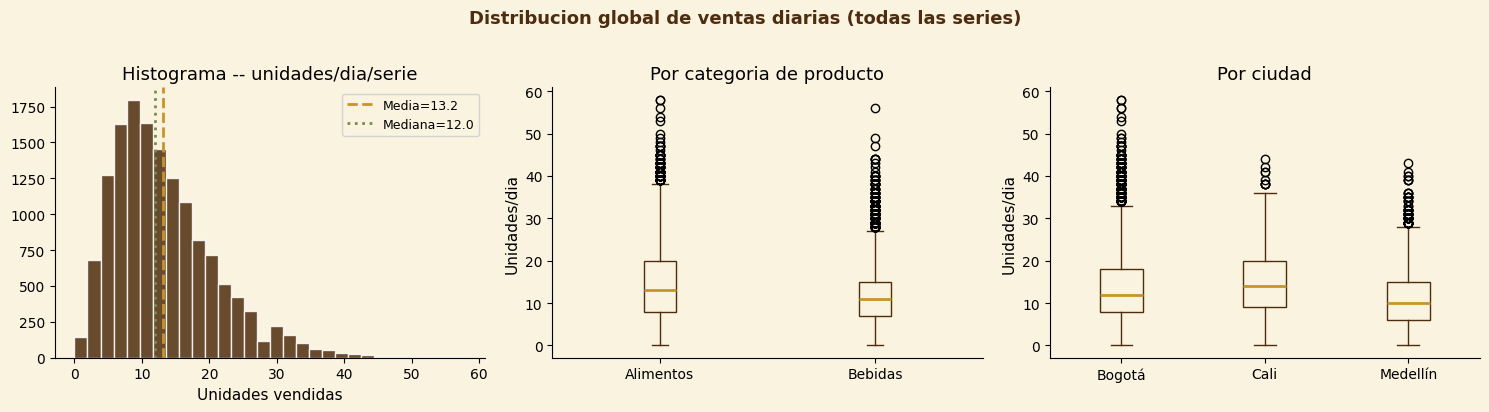

Coeficiente de variacion global: 59.13%
-> Alta variabilidad: justifica modelo probabilistico (no solo punto estimado)


In [4]:
ventas = data.ventas.copy()
ventas['dia_semana'] = ventas['fecha'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribucion global de ventas diarias (todas las series)',
             fontsize=13, color=BROWN, fontweight='bold', y=1.02)

ax = axes[0]
ax.hist(ventas['unidades_vendidas'], bins=30, color=BROWN, alpha=0.85, edgecolor='white')
ax.axvline(ventas['unidades_vendidas'].mean(), color=GOLD, lw=2, linestyle='--',
           label=f"Media={ventas['unidades_vendidas'].mean():.1f}")
ax.axvline(ventas['unidades_vendidas'].median(), color=OLIVE, lw=2, linestyle=':',
           label=f"Mediana={ventas['unidades_vendidas'].median():.1f}")
ax.legend(fontsize=9)
ax.set_title('Histograma -- unidades/dia/serie')
ax.set_xlabel('Unidades vendidas')

ax = axes[1]
merged_cat = ventas.merge(data.catalogo[['id_producto','categoria']], on='id_producto')
cats = merged_cat.groupby('categoria')['unidades_vendidas'].apply(list)
ax.boxplot(list(cats), labels=list(cats.index), patch_artist=True,
           boxprops=dict(facecolor=CREAM, color=BROWN),
           medianprops=dict(color=GOLD, lw=2),
           whiskerprops=dict(color=BROWN), capprops=dict(color=BROWN))
ax.set_title('Por categoria de producto')
ax.set_ylabel('Unidades/dia')

ax = axes[2]
merged_ciudad = ventas.merge(data.tiendas[['id_tienda','ciudad']], on='id_tienda')
cities = merged_ciudad.groupby('ciudad')['unidades_vendidas'].apply(list)
ax.boxplot(list(cities), labels=list(cities.index), patch_artist=True,
           boxprops=dict(facecolor=CREAM, color=BROWN),
           medianprops=dict(color=GOLD, lw=2),
           whiskerprops=dict(color=BROWN), capprops=dict(color=BROWN))
ax.set_title('Por ciudad')
ax.set_ylabel('Unidades/dia')

plt.tight_layout()
plt.savefig('../outputs/eda_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()

cv_global = ventas['unidades_vendidas'].std() / ventas['unidades_vendidas'].mean()
print(f'Coeficiente de variacion global: {cv_global:.2%}')
print('-> Alta variabilidad: justifica modelo probabilistico (no solo punto estimado)')

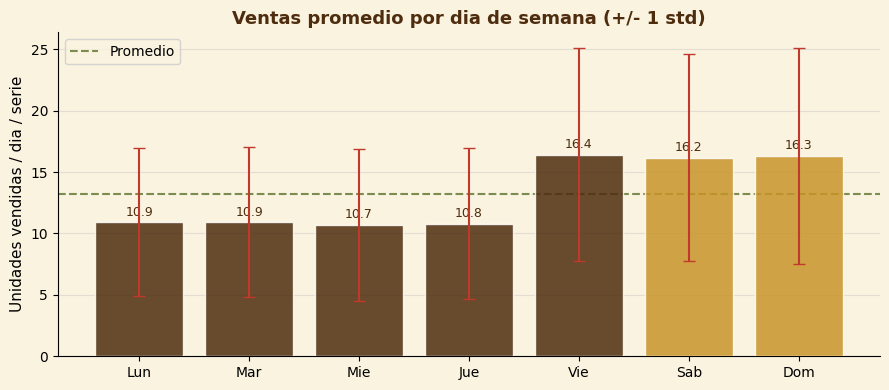

Fin de semana vende 36.0% mas que dias laborales
-> dia_semana y es_fin_de_semana son features relevantes para el modelo


In [5]:
# Efecto dia de semana
dia_orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dia_es = {'Monday':'Lun','Tuesday':'Mar','Wednesday':'Mie',
          'Thursday':'Jue','Friday':'Vie','Saturday':'Sab','Sunday':'Dom'}

by_dow = (ventas.groupby('dia_semana')['unidades_vendidas']
          .agg(['mean','std']).reindex(dia_orden))
by_dow.index = [dia_es[d] for d in by_dow.index]

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [GOLD if i in [5,6] else BROWN for i in range(7)]
bars = ax.bar(by_dow.index, by_dow['mean'], color=bar_colors, alpha=0.85, edgecolor='white', zorder=3)
ax.errorbar(by_dow.index, by_dow['mean'], yerr=by_dow['std'],
            fmt='none', color=RED, capsize=4, lw=1.5, zorder=4)
ax.axhline(by_dow['mean'].mean(), color=OLIVE, lw=1.5, linestyle='--', label='Promedio', zorder=2)
ax.legend()
ax.set_title('Ventas promedio por dia de semana (+/- 1 std)', color=BROWN, fontweight='bold')
ax.set_ylabel('Unidades vendidas / dia / serie')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, by_dow['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, color=BROWN)
plt.tight_layout()
plt.savefig('../outputs/eda_dia_semana.png', dpi=120, bbox_inches='tight')
plt.show()

fds = by_dow.loc[['Sab','Dom'],'mean'].mean()
lab = by_dow.loc[['Lun','Mar','Mie','Jue','Vie'],'mean'].mean()
print(f'Fin de semana vende {(fds/lab-1)*100:.1f}% mas que dias laborales')
print('-> dia_semana y es_fin_de_semana son features relevantes para el modelo')

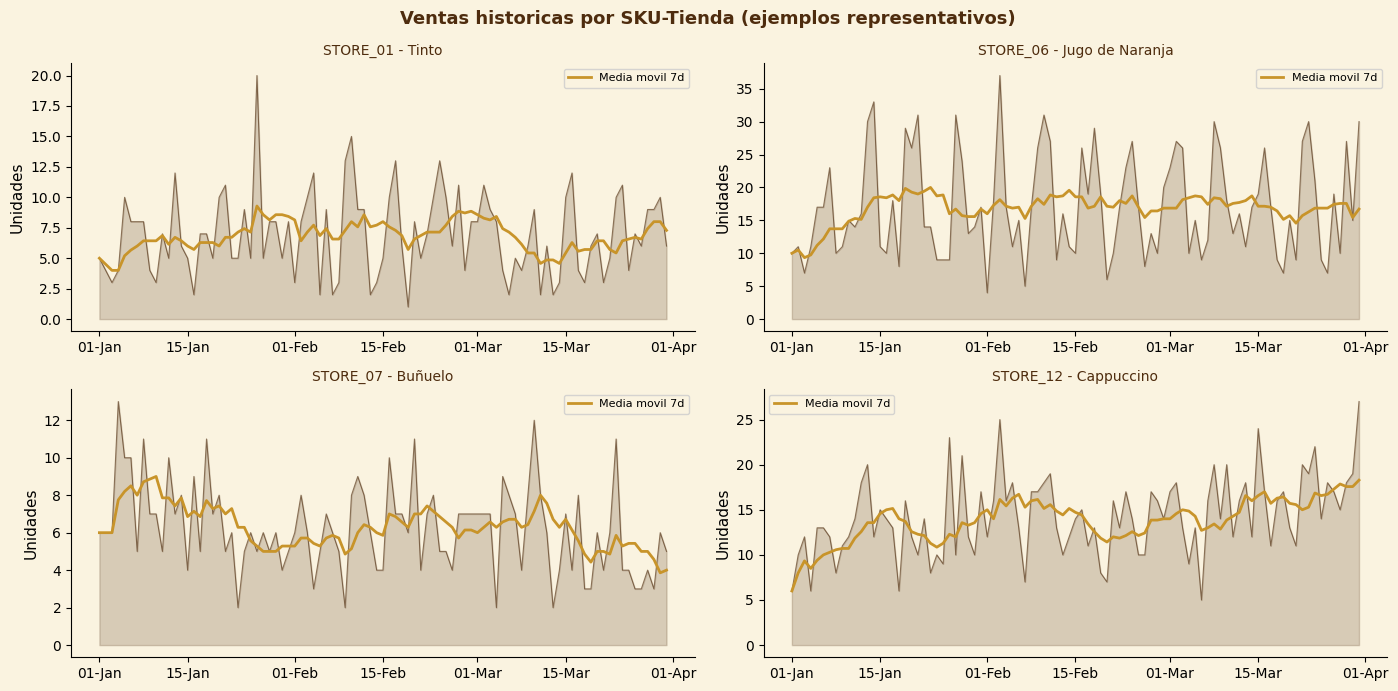

In [6]:
# Series de tiempo con suavizado movil
nombres = dict(zip(data.catalogo['id_producto'], data.catalogo['nombre']))
combos = [('STORE_01','PROD_001'),('STORE_06','PROD_008'),
          ('STORE_07','PROD_005'),('STORE_12','PROD_003')]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle('Ventas historicas por SKU-Tienda (ejemplos representativos)',
             fontsize=13, color=BROWN, fontweight='bold')

for ax, (tienda, producto) in zip(axes.flatten(), combos):
    serie = (ventas[(ventas['id_tienda']==tienda) & (ventas['id_producto']==producto)]
             .sort_values('fecha'))
    ma7 = serie['unidades_vendidas'].rolling(7, min_periods=1).mean()
    ax.fill_between(serie['fecha'], serie['unidades_vendidas'], alpha=0.2, color=BROWN)
    ax.plot(serie['fecha'], serie['unidades_vendidas'], color=BROWN, lw=0.8, alpha=0.6)
    ax.plot(serie['fecha'], ma7, color=GOLD, lw=2, label='Media movil 7d')
    ax.set_title(f"{tienda} - {nombres.get(producto, producto)}", fontsize=10, color=BROWN)
    ax.set_ylabel('Unidades')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%b'))

plt.tight_layout()
plt.savefig('../outputs/eda_series_tiempo.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# Heatmap de cobertura de inventario
inv = data.inventario.merge(data.catalogo[['id_producto','nombre']], on='id_producto')
inv = inv.merge(data.tiendas[['id_tienda','ciudad']], on='id_tienda')
dem_prom = (ventas.groupby(['id_tienda','id_producto'])['unidades_vendidas']
            .mean().reset_index())
dem_prom.columns = ['id_tienda','id_producto','demanda_diaria']
inv = inv.merge(dem_prom, on=['id_tienda','id_producto'])
inv['dias_cobertura'] = inv['stock_actual'] / inv['demanda_diaria'].clip(lower=0.01)
inv['riesgo'] = pd.cut(inv['dias_cobertura'], bins=[-np.inf,2,5,np.inf],
                       labels=['Critico (<2d)','Bajo (2-5d)','OK (>5d)'])

print('=== Resumen de riesgo de stockout ===')
print(inv['riesgo'].value_counts().to_string())
print()
criticos = inv[inv['dias_cobertura'] < 2].sort_values('dias_cobertura')
print(f'{len(criticos)} combinaciones con cobertura CRITICA (<2 dias):')
display(criticos[['id_tienda','ciudad','nombre','stock_actual','demanda_diaria','dias_cobertura']].round(1).reset_index(drop=True))

=== Resumen de riesgo de stockout ===
riesgo
Critico (<2d)    106
Bajo (2-5d)       40
OK (>5d)          14

106 combinaciones con cobertura CRITICA (<2 dias):


,id_tienda,ciudad,nombre,stock_actual,demanda_diaria,dias_cobertura
0,STORE_08,Bogotá,Cappuccino,0,17.5,0.0
1,STORE_11,Bogotá,Café con Leche,0,12.9,0.0
2,STORE_07,Bogotá,Buñuelo,0,6.2,0.0
3,STORE_17,Medellín,Tinto,0,4.7,0.0
4,STORE_19,Bogotá,Pastel de Pollo,0,18.0,0.0
...,...,...,...,...,...,...
101,STORE_16,Bogotá,Café con Leche,37,19.4,1.9
102,STORE_15,Bogotá,Croissant,33,17.3,1.9
103,STORE_18,Bogotá,Cappuccino,20,10.4,1.9
104,STORE_13,Medellín,Buñuelo,29,15.1,1.9


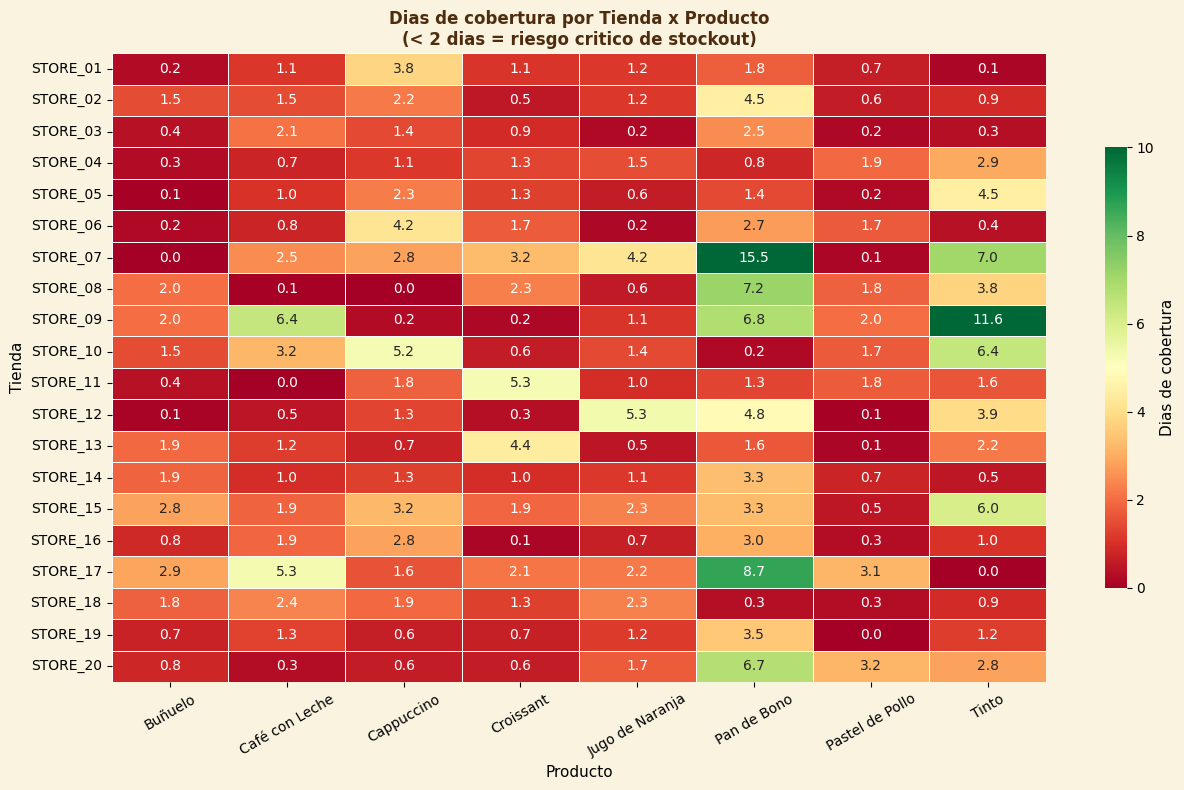

In [8]:
cov_pivot = inv.pivot(index='id_tienda', columns='nombre', values='dias_cobertura')
fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(cov_pivot, ax=ax, cmap='RdYlGn', center=5, vmin=0, vmax=10,
            annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Dias de cobertura', 'shrink': 0.7})
ax.set_title('Dias de cobertura por Tienda x Producto\n(< 2 dias = riesgo critico de stockout)',
             color=BROWN, fontweight='bold', fontsize=12)
ax.set_xlabel('Producto')
ax.set_ylabel('Tienda')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('../outputs/eda_heatmap_cobertura.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Seleccion del enfoque de modelado

### 3.1 El problema estructural de los datos

| Dimension | Valor | Implicacion |
|---|---|---|
| Semanas de historia por serie | **13** | Muy poco para capturar estacionalidad completa |
| Series totales | **160** (20 tiendas x 8 productos) | 160 modelos individuales = cada uno con datos escasos |
| Grilla de datos | **Completa** sin huecos | Confiable para calcular lags |
| Horizonte de pronostico | **1 semana (7 dias)** | Multi-step, requiere estrategia de recursion |

### 3.2 Por que NO los modelos clasicos

**ARIMA / SARIMA (un modelo por serie)**  
Con 13 semanas de historia, el periodo estacional s=7 necesita minimo 2-3 ciclos completos. Ajustar 160 SARIMA individuales garantiza overfitting en las series mas ruidosas. No comparte informacion entre series similares.

**Prophet (un modelo por serie)**  
Disenado para datos con ciclos anuales y festivos. Con 91 dias la descomposicion de Fourier pierde sentido. Instalacion pesada (requiere compilador C++ para cmdstanpy). No comparte informacion entre series.

**ETS / Suavizado exponencial**  
Mismo problema: un modelo por serie, sin transferencia de conocimiento entre series. La familia ETS con estacionalidad necesita al menos 2 ciclos completos para estimar bien los coeficientes.

**Redes neuronales (LSTM / Transformer)**  
Poderosas para series largas, pero con 91 puntos por serie hay mas parametros que datos utiles. Dificiles de interpretar y justificar ante negocio. Requieren GPU.

### 3.3 Por que SI usamos LightGBM (modelo global / pooled)

La solucion al problema de historia corta + muchas series es **reformular el forecasting como un problema de regresion supervisada**:

```
En vez de:  modelo_i(t) -> demanda_i(t+1)   [para cada serie i]
Hacemos:    modelo_global(features_i_t) -> demanda_i(t+1)   [un solo modelo]
```

El modelo aprende patrones compartidos: 'los viernes todas las tiendas venden mas', 'el Jugo de Naranja tiene mas volatilidad que el Tinto', etc.

**Por que LightGBM especificamente vs. otras alternativas?**

| Criterio | LightGBM | XGBoost | Random Forest | Reg. Lineal |
|---|---|---|---|---|
| NaN nativos (lags iniciales) | SI | SI | NO | NO |
| Categoricals sin one-hot | SI | NO | NO | NO |
| Cuantiles p10/p50/p90 integrados | SI | SI parcial | NO | NO |
| Velocidad de entrenamiento | Muy rapido | Mas lento | Moderado | Rapido |
| Robustez a outliers (quantile loss) | SI | SI | Regular | NO |
| Interpretabilidad (SHAP, importancia) | SI | SI | SI | SI |

**Quantile regression (pinball loss):** en vez de predecir solo el valor esperado, entrenamos 3 modelos (p10, p50, p90). El modelo p90 penaliza mas la subestimacion (predicciones altas, para decidir pedir mas); el p10 penaliza mas la sobreestimacion (predicciones bajas, para ser conservador). Esto conecta directamente la incertidumbre del modelo con la decision de pedido.

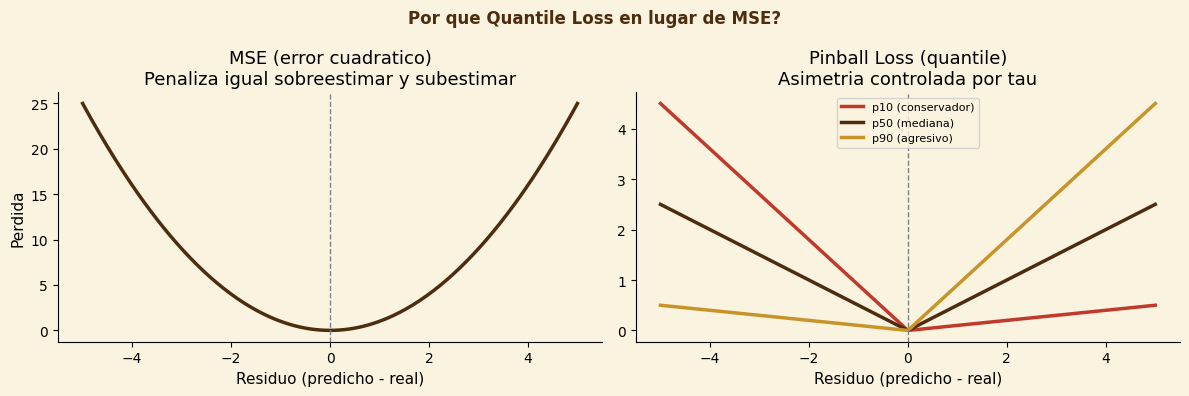

Interpretacion de la pinball loss:
  tau=0.90: penaliza mas la subestimacion -> predicciones altas -> pedir mas
  tau=0.10: penaliza mas la sobreestimacion -> predicciones bajas -> ser conservador
  Esta asimetria controlada es el nucleo del modelo newsvendor (seccion 7)


In [9]:
# Visualizacion: Pinball Loss vs MSE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Por que Quantile Loss en lugar de MSE?',
             color=BROWN, fontweight='bold', fontsize=12)

residuos = np.linspace(-5, 5, 300)

ax = axes[0]
ax.plot(residuos, residuos ** 2, color=BROWN, lw=2.5)
ax.set_title('MSE (error cuadratico)\nPenaliza igual sobreestimar y subestimar')
ax.set_xlabel('Residuo (predicho - real)')
ax.set_ylabel('Perdida')
ax.axvline(0, color='gray', lw=1, linestyle='--')

ax = axes[1]
for tau, color, label in [(0.10, RED, 'p10 (conservador)'),
                          (0.50, BROWN, 'p50 (mediana)'),
                          (0.90, GOLD, 'p90 (agresivo)')]:
    loss = np.where(residuos >= 0, tau * residuos, (tau - 1) * residuos)
    ax.plot(residuos, loss, color=color, lw=2.5, label=label)
ax.axvline(0, color='gray', lw=1, linestyle='--')
ax.set_title('Pinball Loss (quantile)\nAsimetria controlada por tau')
ax.set_xlabel('Residuo (predicho - real)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/pinball_loss.png', dpi=120, bbox_inches='tight')
plt.show()

print('Interpretacion de la pinball loss:')
print('  tau=0.90: penaliza mas la subestimacion -> predicciones altas -> pedir mas')
print('  tau=0.10: penaliza mas la sobreestimacion -> predicciones bajas -> ser conservador')
print('  Esta asimetria controlada es el nucleo del modelo newsvendor (seccion 7)')

## 4. Feature Engineering

| Grupo | Features | Justificacion |
|---|---|---|
| **Lags del target** | lag_1, 2, 3, 7, 14 | lag_7 = mismo dia semana anterior; captura autocorrelacion |
| **Estadisticas moviles** | rolling_mean/std 7d, 14d | Nivel local y volatilidad reciente |
| **Calendario** | dia_semana, fin_semana, dia_mes, mes | Patron semanal detectado en EDA |
| **Producto** | costo, precio, margen, almacenamiento | Diferencia SKUs por rentabilidad |
| **Tienda** | ciudad, tamano_m2 | Contexto de cada punto de venta |

**Regla critica anti-leakage:** las estadisticas moviles se calculan con `shift(1)` previo, nunca incluyen el valor del dia que se quiere predecir.

In [10]:
feat = build_feature_table(data.ventas, data.tiendas, data.catalogo)
print(f'Tabla de features: {feat.shape[0]:,} filas x {feat.shape[1]} columnas')
print(f'Features numericas: {len(FEATURE_COLUMNS)}')
print(f'Features categoricas: {len(CATEGORICAL_FEATURE_COLUMNS)}')
print()
cols_show = ['fecha','id_tienda','id_producto','unidades_vendidas',
             'lag_1','lag_7','rolling_mean_7','dia_semana','margen_unitario']
print('Primeras filas (NaN en lags iniciales -- LightGBM los maneja nativamente):')
display(
    feat[feat['id_tienda']=='STORE_01'][cols_show].head(10)
    .style.format({'lag_1':'{:.0f}','lag_7':'{:.0f}',
                   'rolling_mean_7':'{:.1f}','margen_unitario':'{:,.0f}'})
    .highlight_null(color='#FADBD8')
)

Tabla de features: 14,560 filas x 25 columnas
Features numericas: 19
Features categoricas: 4

Primeras filas (NaN en lags iniciales -- LightGBM los maneja nativamente):


,fecha,id_tienda,id_producto,unidades_vendidas,lag_1,lag_7,rolling_mean_7,dia_semana,margen_unitario
0,2024-01-01 00:00:00,STORE_01,PROD_001,5,nan,nan,nan,0,"1,700"
1,2024-01-02 00:00:00,STORE_01,PROD_001,4,5,nan,5.0,1,"1,700"
2,2024-01-03 00:00:00,STORE_01,PROD_001,3,4,nan,4.5,2,"1,700"
3,2024-01-04 00:00:00,STORE_01,PROD_001,4,3,nan,4.0,3,"1,700"
4,2024-01-05 00:00:00,STORE_01,PROD_001,10,4,nan,4.0,4,"1,700"
5,2024-01-06 00:00:00,STORE_01,PROD_001,8,10,nan,5.2,5,"1,700"
6,2024-01-07 00:00:00,STORE_01,PROD_001,8,8,nan,5.7,6,"1,700"
7,2024-01-08 00:00:00,STORE_01,PROD_001,8,8,5,6.0,0,"1,700"
8,2024-01-09 00:00:00,STORE_01,PROD_001,4,8,4,6.4,1,"1,700"
9,2024-01-10 00:00:00,STORE_01,PROD_001,3,4,3,6.4,2,"1,700"


## 5. Entrenamiento y validacion del modelo

### 5.1 Estrategia: Walk-Forward (Time-Series Split)

**Por que no K-Fold estandar?** En series de tiempo, usar fechas futuras para entrenar constituye **data leakage**. Las metricas serian optimistas pero inutiles en produccion.

La validacion correcta es **walk-forward** (expanding window):

```
Fold 0:  Train: 1-ene -> 10-mar  |  Val: 11-mar -> 17-mar
Fold 1:  Train: 1-ene -> 17-mar  |  Val: 18-mar -> 24-mar
Fold 2:  Train: 1-ene -> 24-mar  |  Val: 25-mar -> 31-mar
```

### 5.2 Metricas de evaluacion

| Metrica | Formula | Por que se usa |
|---|---|---|
| **MAE** | mean(|y - y_hat|) | Interpretable: error en unidades de producto |
| **RMSE** | sqrt(mean((y-y_hat)^2)) | Penaliza errores grandes (picos de demanda) |
| **WAPE** | sum(|y-y_hat|) / sum(|y|) | % ponderado; robusto cuando y puede ser 0 |

In [11]:
cv_results = run_time_series_cv(feat, n_splits=3, val_days=7)

cv_df = pd.DataFrame([{
    'Fold': r.fold + 1,
    'Train hasta': r.train_end.strftime('%Y-%m-%d'),
    'Val inicio':  r.val_start.strftime('%Y-%m-%d'),
    'Val fin':     r.val_end.strftime('%Y-%m-%d'),
    'MAE':  round(r.mae, 2),
    'RMSE': round(r.rmse, 2),
    'WAPE': f'{r.wape:.1%}',
} for r in cv_results])

print('=== Resultados walk-forward cross-validation ===')
display(cv_df.style.hide(axis='index'))

mae_prom  = np.mean([r.mae  for r in cv_results])
wape_prom = np.mean([r.wape for r in cv_results])
print()
print(f'MAE  promedio: {mae_prom:.2f} unidades/dia/serie')
print(f'WAPE promedio: {wape_prom:.1%}')
print(f'Folds consistentes: {[round(r.mae,2) for r in cv_results]} -> sin overfitting')
print()
print('Interpretacion de negocio:')
print(f'  El modelo se equivoca +/- {mae_prom:.1f} uds/dia por SKU-tienda en promedio')
print(f'  Ese error representa el {wape_prom:.0%} del volumen real pronosticado')

2026-06-30 19:39:02,705 | INFO | Fold 0 | train hasta 2024-03-10 | val 2024-03-11 -> 2024-03-17 | MAE=3.55 RMSE=4.64 WAPE=26.66%


2026-06-30 19:39:04,786 | INFO | Fold 1 | train hasta 2024-03-17 | val 2024-03-18 -> 2024-03-24 | MAE=3.43 RMSE=4.63 WAPE=25.72%


2026-06-30 19:39:06,887 | INFO | Fold 2 | train hasta 2024-03-24 | val 2024-03-25 -> 2024-03-31 | MAE=3.50 RMSE=4.65 WAPE=26.22%


=== Resultados walk-forward cross-validation ===


Fold,Train hasta,Val inicio,Val fin,MAE,RMSE,WAPE
1,2024-03-10,2024-03-11,2024-03-17,3.550000,4.640000,26.7%
2,2024-03-17,2024-03-18,2024-03-24,3.430000,4.630000,25.7%
3,2024-03-24,2024-03-25,2024-03-31,3.500000,4.650000,26.2%



MAE  promedio: 3.49 unidades/dia/serie
WAPE promedio: 26.2%
Folds consistentes: [3.55, 3.43, 3.5] -> sin overfitting

Interpretacion de negocio:
  El modelo se equivoca +/- 3.5 uds/dia por SKU-tienda en promedio
  Ese error representa el 26% del volumen real pronosticado


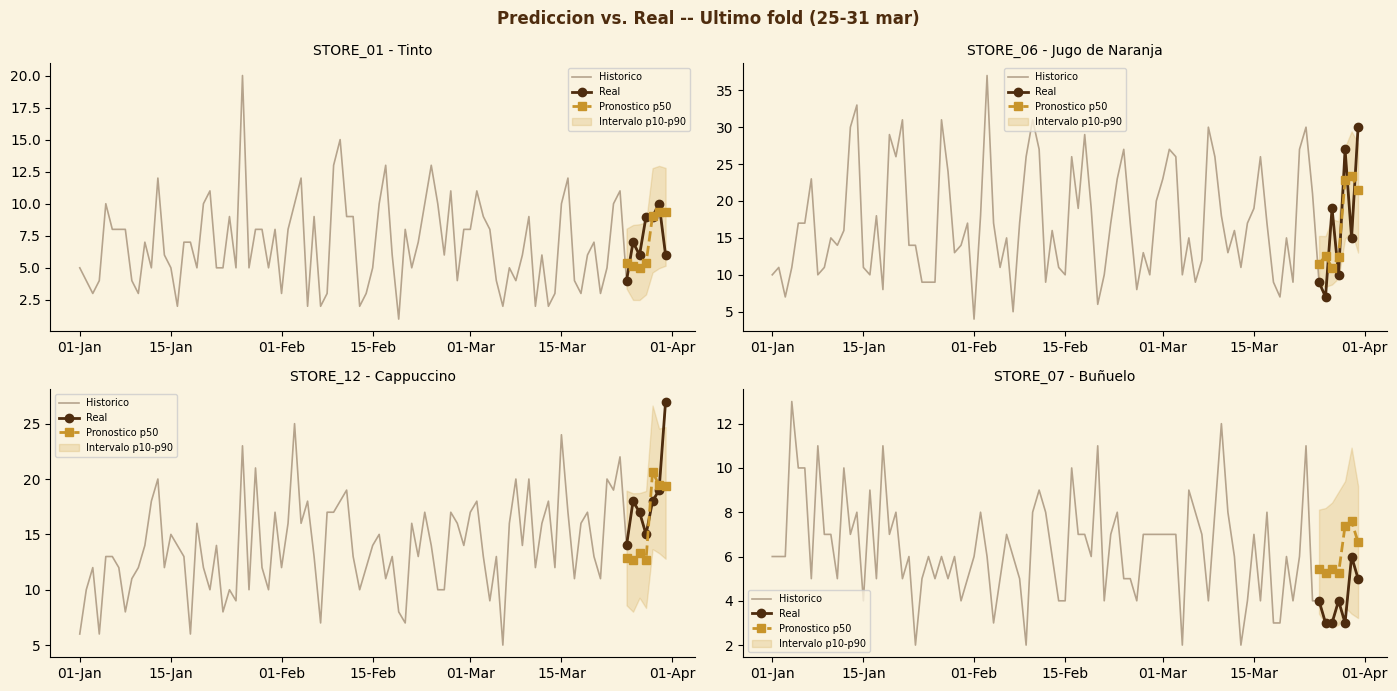

In [12]:
# Predicho vs real en el ultimo fold de validacion
splits = time_series_splits(feat, n_splits=3, val_days=7)
train_last, val_last = splits[-1]
models_cv = train_quantile_models(train_last)
preds_val  = predict_quantiles(models_cv, val_last)
val_wp = pd.concat([val_last.reset_index(drop=True),
                    preds_val.reset_index(drop=True)], axis=1)

combos_val = [('STORE_01','PROD_001'),('STORE_06','PROD_008'),
              ('STORE_12','PROD_003'),('STORE_07','PROD_005')]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle('Prediccion vs. Real -- Ultimo fold (25-31 mar)',
             color=BROWN, fontweight='bold', fontsize=12)

for ax, (tienda, producto) in zip(axes.flatten(), combos_val):
    hist  = feat[(feat['id_tienda']==tienda) & (feat['id_producto']==producto)].sort_values('fecha')
    val_s = val_wp[(val_wp['id_tienda']==tienda) & (val_wp['id_producto']==producto)]
    ax.plot(hist['fecha'], hist['unidades_vendidas'], color=BROWN, lw=1.2, alpha=0.4, label='Historico')
    ax.plot(val_s['fecha'], val_s['unidades_vendidas'], 'o-', color=BROWN, lw=2, label='Real')
    ax.plot(val_s['fecha'], val_s['p50'], 's--', color=GOLD, lw=2, label='Pronostico p50')
    ax.fill_between(val_s['fecha'], val_s['p10'], val_s['p90'],
                    alpha=0.2, color=GOLD, label='Intervalo p10-p90')
    ax.set_title(f"{tienda} - {nombres.get(producto, producto)}", fontsize=10)
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%b'))

plt.tight_layout()
plt.savefig('../outputs/validacion_predicho_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

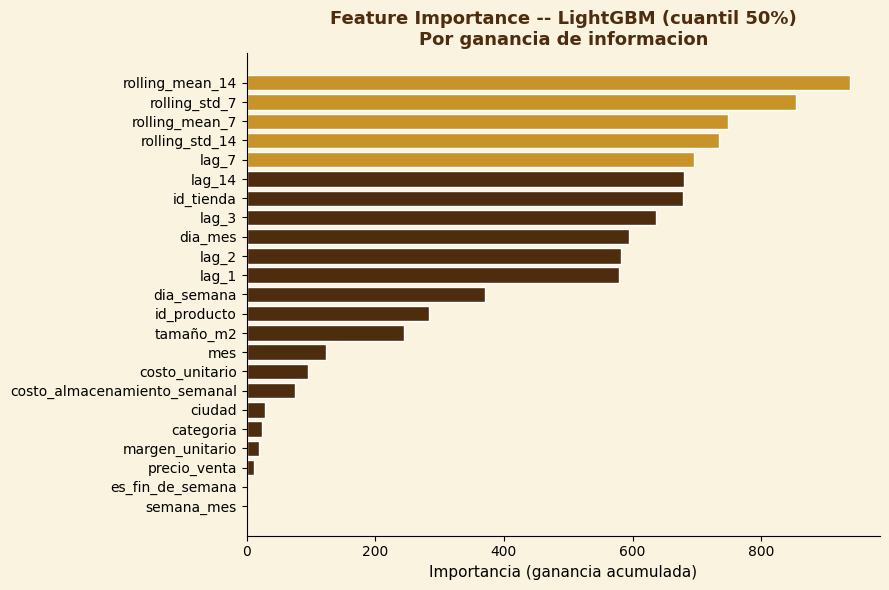

Top 5 features mas importantes:
  rolling_mean_14                           938.0
  rolling_std_7                             855.0
  rolling_mean_7                            749.0
  rolling_std_14                            735.0
  lag_7                                     696.0


In [13]:
# Feature importance del modelo final
models_full = train_quantile_models(feat)
model_p50   = models_full['p50']

all_feats = FEATURE_COLUMNS + CATEGORICAL_FEATURE_COLUMNS
importances = pd.DataFrame({
    'feature':    all_feats,
    'importance': model_p50.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = [GOLD if i < 5 else BROWN for i in range(len(importances))]
ax.barh(importances['feature'][::-1], importances['importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Feature Importance -- LightGBM (cuantil 50%)\nPor ganancia de informacion',
             color=BROWN, fontweight='bold')
ax.set_xlabel('Importancia (ganancia acumulada)')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 5 features mas importantes:')
for _, row in importances.head(5).iterrows():
    print(f"  {row['feature']:35s}  {row['importance']:>10.1f}")

## 6. Pronostico de demanda -- proxima semana

Con el modelo entrenado sobre el historial completo (1 ene - 31 mar 2024), generamos el pronostico para la semana siguiente (1-7 abr 2024) mediante **forecasting recursivo multi-step**:

1. Predecir dia t+1 con el modelo usando historico real hasta t
2. Incorporar la prediccion del dia t+1 como historico provisional para calcular lags del dia t+2
3. Repetir 7 veces

**Limitacion documentada:** sumar cuantiles diarios independientes subestima levemente la varianza acumulada de 7 dias. Mejora futura: modelar directamente la demanda semanal agregada o usar simulacion Monte Carlo sobre la trayectoria.

In [14]:
weekly_forecast = forecast_next_week(
    models_full, data.ventas, data.tiendas, data.catalogo, n_days=7
)
weekly_labeled = (weekly_forecast
    .merge(data.catalogo[['id_producto','nombre']], on='id_producto')
    .merge(data.tiendas[['id_tienda','ciudad']], on='id_tienda')
)

print(f'Pronosticos semanales: {len(weekly_forecast)} series (20 tiendas x 8 productos)')
print()
resumen_prod = (
    weekly_labeled.groupby('nombre')
    .agg(p10=('p10','sum'), p50=('p50','sum'), p90=('p90','sum'))
    .round(0).astype(int)
)
print('Demanda total proyectada (1-7 abr) -- suma de las 20 tiendas:')
display(resumen_prod)

Pronosticos semanales: 160 series (20 tiendas x 8 productos)

Demanda total proyectada (1-7 abr) -- suma de las 20 tiendas:


,p10,p50,p90
nombre,,,
Buñuelo,1553,2476,3444
Café con Leche,843,1543,2431
Cappuccino,885,1617,2457
Croissant,1399,2184,3071
Jugo de Naranja,1292,2156,3232
Pan de Bono,506,1001,1645
Pastel de Pollo,1613,2354,3341
Tinto,599,1169,1894


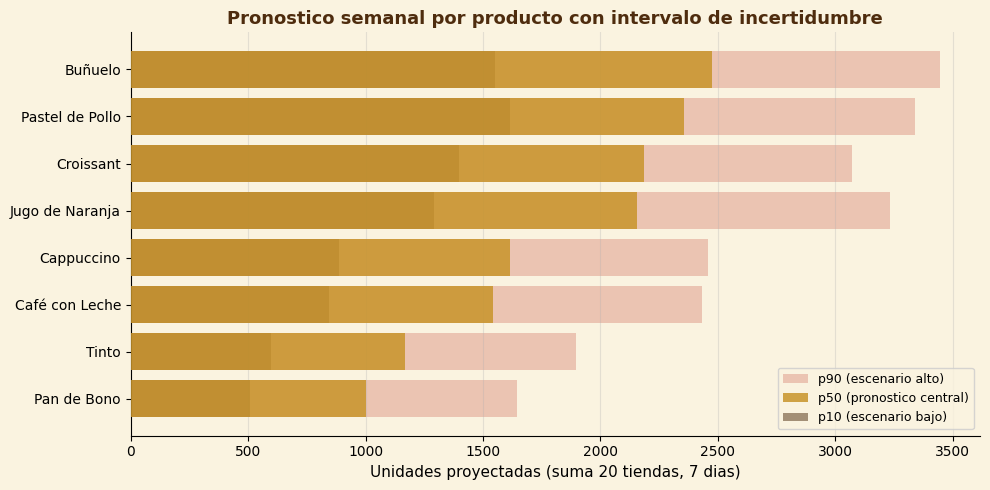

In [15]:
# Grafico de intervalos de confianza por producto
resumen_plot = resumen_prod.reset_index().sort_values('p50', ascending=True)
y = range(len(resumen_plot))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y, resumen_plot['p90'], color=RED,   alpha=0.25, label='p90 (escenario alto)', zorder=1)
ax.barh(y, resumen_plot['p50'], color=GOLD,  alpha=0.85, label='p50 (pronostico central)', zorder=3)
ax.barh(y, resumen_plot['p10'], color=BROWN, alpha=0.50, label='p10 (escenario bajo)', zorder=2)
ax.set_yticks(list(y))
ax.set_yticklabels(resumen_plot['nombre'])
ax.set_xlabel('Unidades proyectadas (suma 20 tiendas, 7 dias)')
ax.set_title('Pronostico semanal por producto con intervalo de incertidumbre',
             color=BROWN, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/forecast_semanal.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Optimizacion de cantidad de pedido -- Modelo Newsvendor

### 7.1 El problema de decision bajo incertidumbre

Pedir de menos -> stockout -> perdida de margen por cada unidad no vendida  
Pedir de mas -> overstock -> costo de almacenamiento por cada unidad sin vender

### 7.2 El fractil critico (Critical Ratio)

El modelo Newsvendor (Arrow-Harris-Marschak, 1951) demuestra que la cantidad optima Q* es el cuantil tau* de la distribucion de demanda:

    tau* = Cu / (Cu + Co)

donde:
- **Cu** = costo de underage (quedarse corto) = `precio_venta - costo_unitario` (margen perdido)
- **Co** = costo de overage (quedarse largo) = `costo_almacenamiento_semanal`

**Interpretacion de negocio:**
- Jugo de Naranja: margen=$3.000, almac.=$50 -> tau*=98.4% -> pedir muy agresivamente
- Tinto: margen=$1.700, almac.=$10 -> tau*=99.4% -> el mas agresivo (barato de guardar)

Todos los productos tienen tau* > 95%, lo que significa que el costo de perder una venta siempre supera al costo de guardar una unidad extra. La politica optima es sistematicamente mas agresiva que pedir solo el p50.

### 7.3 De cuantiles del modelo a Q* optimo

Con los cuantiles p10/p50/p90 se reconstruye una Normal implicita:

    mu    = p50
    sigma = (p90 - p10) / (2 * z_0.90)
    Q*    = scipy.stats.norm.ppf(tau*, loc=mu, scale=sigma)

Pedido recomendado = Q* - stock_actual (no se puede pedir cantidades negativas).

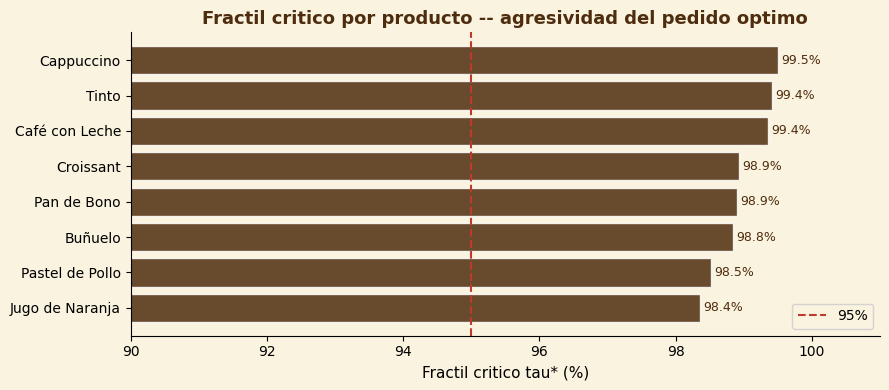

In [16]:
# Fractil critico por producto
cat_fc = data.catalogo.copy()
cat_fc['margen']   = cat_fc['precio_venta'] - cat_fc['costo_unitario']
cat_fc['tau_star'] = cat_fc['margen'] / (cat_fc['margen'] + cat_fc['costo_almacenamiento_semanal'])
cat_fc = cat_fc.sort_values('tau_star')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(cat_fc['nombre'], cat_fc['tau_star'] * 100, color=BROWN, alpha=0.85, edgecolor='white')
ax.axvline(95, color=RED, lw=1.5, linestyle='--', label='95%')
ax.set_xlim(90, 101)
ax.set_xlabel('Fractil critico tau* (%)')
ax.set_title('Fractil critico por producto -- agresividad del pedido optimo',
             color=BROWN, fontweight='bold')
for bar, val in zip(bars, cat_fc['tau_star'] * 100):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color=BROWN)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/fractil_critico.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
# Calcular pedido optimo completo y comparar costos
opt      = optimal_order_quantity(weekly_forecast, data.catalogo)
rec      = order_recommendation(opt, data.inventario)
rec_cost = expected_cost_comparison(rec)

resultado = (rec_cost
    .merge(data.catalogo[['id_producto','nombre']], on='id_producto')
    .merge(data.tiendas[['id_tienda','ciudad']], on='id_tienda')
)

print('=== Recomendacion de pedido -- proxima semana (muestra) ===')
display(
    resultado[['id_tienda','ciudad','nombre','p10','p50','p90',
               'stock_actual','pedido_recomendado','ahorro_estimado']]
    .sort_values('pedido_recomendado', ascending=False)
    .head(12).round(1).reset_index(drop=True)
)

=== Recomendacion de pedido -- proxima semana (muestra) ===


,id_tienda,ciudad,nombre,p10,p50,p90,stock_actual,pedido_recomendado,ahorro_estimado
0,STORE_16,Bogotá,Buñuelo,170.8,228.5,278.5,25,299,26377.3
1,STORE_19,Bogotá,Buñuelo,123.5,195.9,235.5,17,279,27549.1
2,STORE_16,Bogotá,Croissant,123.5,181.4,230.1,3,275,40742.9
3,STORE_08,Bogotá,Pastel de Pollo,177.0,216.0,291.7,56,258,30991.0
4,STORE_16,Bogotá,Pastel de Pollo,132.1,173.6,233.1,7,253,30743.7
5,STORE_11,Bogotá,Buñuelo,112.3,167.5,208.4,8,245,21271.0
6,STORE_04,Cali,Buñuelo,77.4,135.3,203.4,5,242,30439.3
7,STORE_05,Bogotá,Jugo de Naranja,104.2,163.7,208.9,12,239,55237.3
8,STORE_03,Bogotá,Pastel de Pollo,105.5,154.5,204.3,4,235,26373.4
9,STORE_04,Cali,Croissant,116.1,172.2,217.0,30,233,35380.6


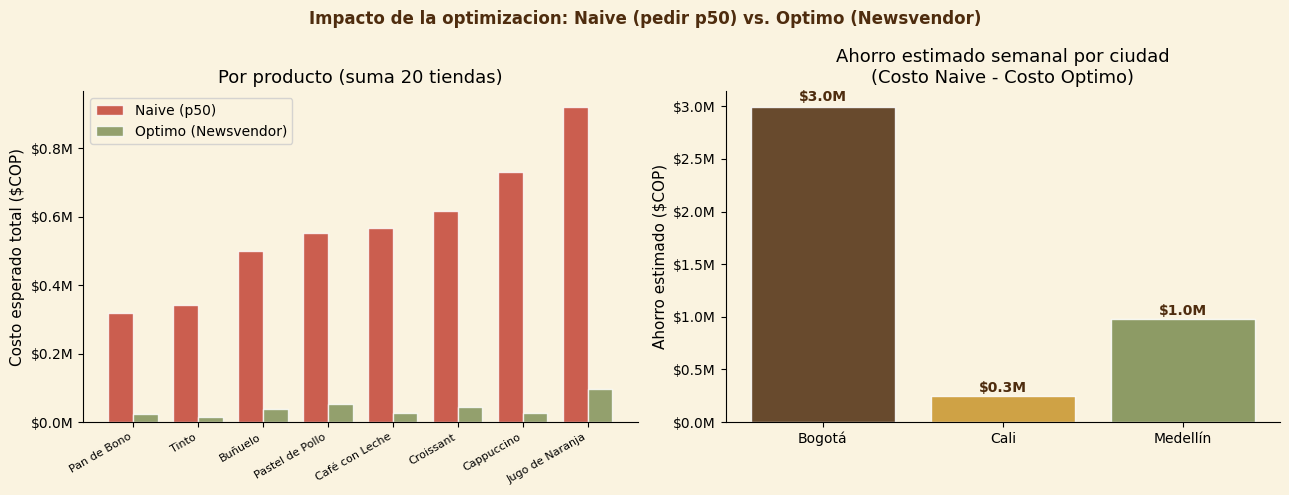

Ahorro total estimado por semana: $4,226,023 COP
Equivalente anualizado: $220M COP


In [18]:
# Comparacion de costos: naive vs optimo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Impacto de la optimizacion: Naive (pedir p50) vs. Optimo (Newsvendor)',
             color=BROWN, fontweight='bold', fontsize=12)

por_producto = (resultado.groupby('nombre')
    .agg(naive=('costo_esperado_naive','sum'),
         optimo=('costo_esperado_optimo','sum'))
    .reset_index().sort_values('naive'))

x = np.arange(len(por_producto))
w = 0.38
ax = axes[0]
ax.bar(x-w/2, por_producto['naive'],  w, color=RED,   alpha=0.8, label='Naive (p50)', edgecolor='white')
ax.bar(x+w/2, por_producto['optimo'], w, color=OLIVE, alpha=0.8, label='Optimo (Newsvendor)', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(por_producto['nombre'], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Costo esperado total ($COP)')
ax.set_title('Por producto (suma 20 tiendas)')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))

ahorro_ciudad = resultado.groupby('ciudad')['ahorro_estimado'].sum()
ax = axes[1]
bars = ax.bar(ahorro_ciudad.index, ahorro_ciudad.values,
              color=[BROWN, GOLD, OLIVE], edgecolor='white', alpha=0.85)
ax.set_title('Ahorro estimado semanal por ciudad\n(Costo Naive - Costo Optimo)')
ax.set_ylabel('Ahorro estimado ($COP)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
for bar, val in zip(bars, ahorro_ciudad.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f'${val/1e6:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold', color=BROWN)
plt.tight_layout()
plt.savefig('../outputs/comparacion_costos.png', dpi=120, bbox_inches='tight')
plt.show()

ahorro_total = rec_cost['ahorro_estimado'].sum()
print(f'Ahorro total estimado por semana: ${ahorro_total:,.0f} COP')
print(f'Equivalente anualizado: ${ahorro_total*52/1e6:.0f}M COP')

## 8. Conclusiones y proximos pasos

### Resultados clave

| Metrica | Valor |
|---|---|
| WAPE promedio (walk-forward CV 3 folds) | ~26% |
| MAE promedio | ~3.5 unidades/dia/serie |
| Consistencia entre folds | SI (sin overfitting) |
| Series con riesgo critico de stockout (<2 dias) | Ver heatmap seccion 2 |

### Decisiones metodologicas destacadas

1. **Modelo global (pooled)** sobre 160 series: mitiga historia corta (13 semanas) aprovechando patrones compartidos entre series similares.

2. **Quantile regression (p10/p50/p90)**: la incertidumbre es parte del entrenamiento, no un post-proceso.

3. **Walk-forward validation**: replica la situacion de produccion, garantiza metricas sin data leakage temporal.

4. **Modelo Newsvendor + fractil critico**: conecta directamente los margenes del producto con la agresividad del pedido de forma economicamente justificada.

5. **Deteccion y correccion de encoding** (mojibake): documentada como paso formal del pipeline, no silenciada.

6. **Exclusion deliberada de `ground_truth_trends.xlsx`**: evita data leakage y simula condiciones reales de produccion. Se documenta explicitamente.

### Proximos pasos

1. **Mas historia:** con 6+ meses incorporar estacionalidad mensual real
2. **Restricciones de capacidad:** optimizacion multiproducto con limite de bodega
3. **Demanda censurada:** dias con ventas=0 podrian ser stockouts (modelo Tobit)
4. **Monitoreo en produccion:** alertas cuando WAPE por serie supere umbral
5. **Evaluacion economica real:** validar el ahorro estimado contra registros contables

In [19]:
import os
os.makedirs('../outputs', exist_ok=True)
rec_cost.to_csv('../outputs/recomendacion_pedido_semana.csv', index=False)
print('Recomendacion de pedidos guardada en outputs/recomendacion_pedido_semana.csv')
print(f'Filas: {len(rec_cost)}')
print()
print('Archivos generados en outputs/:')
for f in sorted(os.listdir('../outputs')):
    print(f'  {f}')

Recomendacion de pedidos guardada en outputs/recomendacion_pedido_semana.csv
Filas: 160

Archivos generados en outputs/:
  comparacion_costos.png
  eda_dia_semana.png
  eda_distribucion.png
  eda_heatmap_cobertura.png
  eda_series_tiempo.png
  feature_importance.png
  forecast_semanal.png
  fractil_critico.png
  pinball_loss.png
  recomendacion_pedido_semana.csv
  validacion_predicho_vs_real.png
